In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt#data visualization
import seaborn as sns #Seaborn is widely used for creating visually appealing and informative statistical graphics 
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-attack-prediction-dataset/heart_attack_prediction_dataset.csv


In [3]:
# Using the read_csv() function from pandas to read the CSV file containing the heart attack prediction dataset
df=pd.read_csv("/kaggle/input/heart-attack-prediction-dataset/heart_attack_prediction_dataset.csv")

In [4]:
# Displaying the first few rows of the DataFrame 'df' using the head() function
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [5]:
# Displaying the last few rows of the DataFrame 'df' using the tail() function
df.tail()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0
8762,ZWN9666,25,Female,356,138/67,75,1,1,0,0,...,9.005234,247338,32.914151,180,7,4,United Kingdom,Europe,Northern Hemisphere,1


In [6]:
# Providing information about the DataFrame 'df', including the data types of each column and memory usage,
# using the info() function
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [7]:
# Generating descriptive statistics for numerical columns of the DataFrame 'df' using the describe() method
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


In [8]:
# Getting the shape (number of rows and columns) of the DataFrame 'df' using the shape attribute
df.shape

(8763, 26)

In [9]:
#Getting the memory usage of each column in the DataFrame 'df' using the memory_usage() method
df.memory_usage()

Index                                128
Patient ID                         70104
Age                                70104
Sex                                70104
Cholesterol                        70104
Blood Pressure                     70104
Heart Rate                         70104
Diabetes                           70104
Family History                     70104
Smoking                            70104
Obesity                            70104
Alcohol Consumption                70104
Exercise Hours Per Week            70104
Diet                               70104
Previous Heart Problems            70104
Medication Use                     70104
Stress Level                       70104
Sedentary Hours Per Day            70104
Income                             70104
BMI                                70104
Triglycerides                      70104
Physical Activity Days Per Week    70104
Sleep Hours Per Day                70104
Country                            70104
Continent       

In [10]:
#step6
# Calculating the memory usage of each column in the DataFrame df
memory_usage = df.memory_usage()
# Summing up the memory usage of all columns in the DataFrame df to get the total memory usage
total_memory_usage = memory_usage.sum()
# Displaying the total memory usage of the DataFrame df
total_memory_usage

1822832

In [11]:
# Getting the column names of the DataFrame df using the columns attribute
columns = df.columns
columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [13]:
# Iterate over each column in the DataFrame
for column in df.columns:
    # Convert integer columns to int16 data type for memory optimization
    if df[column].dtype == "int":
        df[column] = df[column].astype("int16")
    # Convert float columns to float16 data type for memory optimization
    elif df[column].dtype == "float":
        df[column] = df[column].astype("float16")
    # Convert object columns to category data type for memory optimization
    elif df[column].dtype == "object":
        df[column] = df[column].astype("category")

In [14]:
# Step 8: Repeat step 6 after optimizing data types to further reduce memory usage
memory_usage = df.memory_usage()  # Calculate memory usage after optimization
total_memory_usage = memory_usage.sum()  # Calculate total memory usage after optimization
total_memory_usage  # Display the total memory usage after optimization

911097

In [15]:
# Check for duplicated rows in the DataFrame
df.duplicated()
# Retrieve the duplicated rows in the DataFrame
duplicates = df.duplicated()
# Calculate the total number of duplicated rows
total_duplicates = duplicates.sum()
total_duplicates

0

In [16]:
#check for missing values in the Dataframe using the isna() method which returns the Dataframe of the same shape as df
#with True fir missing values and false for non_missing values
#This step commutes the total count of  missing values in each column 
df.isna().sum()


Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

In [17]:
# Step 1: Rename Columns
df = df.rename(columns={
    "Sleep Hours Per Day": "Sleeping Hours",
    "Physical Activity Days Per Week": "Activity per Week",
    "Sedentary Hours Per Day": "Sedentary Hours",
    "Patient ID": "ID"})
df

,ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.613281,-740,31.250000,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.964844,23624,27.187500,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.460938,-26862,28.171875,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648438,-5432,36.468750,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514648,29483,21.812500,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.804688,-26724,19.656250,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833984,21273,24.000000,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375000,-28538,35.406250,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029099,13335,27.296875,114,2,8,Brazil,South America,Southern Hemisphere,0


In [18]:
# Step 2: Calculate and Print
# Total number of people in every Continent
continent_counts = df["Continent"].value_counts()
continent_counts

Continent
Asia             2543
Europe           2241
South America    1362
Australia         884
Africa            873
North America     860
Name: count, dtype: int64

In [19]:
# Total number of Males and Females
gender_counts = df["Sex"].value_counts()
gender_counts

Sex
Male      6111
Female    2652
Name: count, dtype: int64

In [20]:
# Total number of people who Smoke and don't smoke
smoking_counts = df["Smoking"].value_counts()
smoking_counts

Smoking
1    7859
0     904
Name: count, dtype: int64

In [21]:
# Total number of people who are at Heart Attack Risk
risk_counts = df['Heart Attack Risk'].value_counts()
risk_counts

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

In [22]:
# Step 3: Subset/Slice the dataset and Print
# First 10 rows and First 5 columns
#iloc: This is a method in pandas used for selection by position.
#It allows you to select data based on its numerical position in the DataFrame.
df.iloc[:10, :5]

,ID,Age,Sex,Cholesterol,Blood Pressure
0,BMW7812,67,Male,208,158/88
1,CZE1114,21,Male,389,165/93
2,BNI9906,21,Female,324,174/99
3,JLN3497,84,Male,383,163/100
4,GFO8847,66,Male,318,91/88
5,ZOO7941,54,Female,297,172/86
6,WYV0966,90,Male,358,102/73
7,XXM0972,84,Male,220,131/68
8,XCQ5937,20,Male,145,144/105
9,FTJ5456,43,Female,248,160/70


In [23]:
# ALL rows and only the [Age, Continent, Heart Attack Risk] columns
df[["Age","Continent","Heart Attack Risk"]]

,Age,Continent,Heart Attack Risk
0,67,South America,0
1,21,North America,0
2,21,Europe,0
3,84,North America,0
4,66,Asia,0
...,...,...,...
8758,60,Asia,0
8759,28,North America,0
8760,47,South America,1
8761,36,South America,0


In [24]:
df

,ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.613281,-740,31.250000,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.964844,23624,27.187500,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.460938,-26862,28.171875,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648438,-5432,36.468750,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514648,29483,21.812500,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.804688,-26724,19.656250,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833984,21273,24.000000,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375000,-28538,35.406250,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029099,13335,27.296875,114,2,8,Brazil,South America,Southern Hemisphere,0


In [26]:
# Step 4: Delete Column
# Delete Continent column
#del df["Continent"]


In [27]:
# Delete ID column
del df["ID"]

In [28]:
df["Active Hours"] = 24 - df["Sedentary Hours"]
df

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk,Active Hours
0,67,Male,208,158/88,72,0,0,1,0,0,...,-740,31.250000,286,0,6,Argentina,South America,Southern Hemisphere,0,17.390625
1,21,Male,389,165/93,98,1,1,1,1,1,...,23624,27.187500,235,1,7,Canada,North America,Northern Hemisphere,0,19.031250
2,21,Female,324,174/99,72,1,0,0,0,0,...,-26862,28.171875,587,4,4,France,Europe,Northern Hemisphere,0,14.539062
3,84,Male,383,163/100,73,1,1,1,0,1,...,-5432,36.468750,378,3,4,Canada,North America,Northern Hemisphere,0,16.343750
4,66,Male,318,91/88,93,1,1,1,1,0,...,29483,21.812500,231,1,5,Thailand,Asia,Northern Hemisphere,0,22.484375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,Male,121,94/76,61,1,1,1,0,1,...,-26724,19.656250,67,7,7,Thailand,Asia,Northern Hemisphere,0,13.195312
8759,28,Female,120,157/102,73,1,0,0,1,0,...,21273,24.000000,617,4,9,Canada,North America,Northern Hemisphere,0,20.171875
8760,47,Male,250,161/75,105,0,1,1,1,1,...,-28538,35.406250,527,4,4,Brazil,South America,Southern Hemisphere,1,21.625000
8761,36,Male,178,119/67,60,1,0,1,0,0,...,13335,27.296875,114,2,8,Brazil,South America,Southern Hemisphere,0,23.968750


In [29]:
col = ["Age", "Cholesterol", "Income"]

for column in col:
    # Number of values in column
    n = len(df)
    
    # Sum of values in column
    column_sum = df[column].sum()
    
    # Calculate mean
    mean = column_sum / n
    
    # Print mean
    print(f"Mean of {column}: {mean}")


Mean of Age: 53.70797672030127
Mean of Cholesterol: 259.8772110007988
Mean of Income: 724.0012552778729


In [30]:
#calculate mean of given columns using numpy method
col=["Age","Cholesterol","Income"]
mean_values = df[col].mean()
mean_values

Age             53.707977
Cholesterol    259.877211
Income         724.001255
dtype: float64

In [31]:
col = ["Age", "Cholesterol", "Income"]

for i in col:
    # Get total number of values in the column
    n = len(df[i])
    
    # Get all values in the column
    x = df[i]
    
    # Calculate the mean of the column
    x_mean = np.mean(df[i])
    
    # Subtract the mean from each value in the column
    subtraction = x - x_mean
    
    # Square the differences
    squared_differences = subtraction ** 2
    
    # Sum up the squared differences
    sum_of_squares = np.sum(squared_differences)
    
    # Divide the sum of squares by the number of values in the column
    division = sum_of_squares / n-1
    
    # Take the square root of the division to get the standard deviation
    standard_deviation = np.sqrt(division)
    
    # Print the standard deviation for the column
    print(f"Standard deviation of {i}: {standard_deviation}")


Standard deviation of Age: 21.22475196874092
Standard deviation of Cholesterol: 80.85247820357786
Standard deviation of Income: 19603.632565854103


In [32]:
#we will take standard deviation by using numpy function
col = ["Age", "Cholesterol", "Income"]

for i in col:
    # Calculate the sample standard deviation for each column
    standard_deviation = np.std(df[i])
    
    # Print the standard deviation for the column
    print(f"Sample Standard Deviation of {i}: {standard_deviation}")

Sample Standard Deviation of Age: 21.24829631134157
Sample Standard Deviation of Cholesterol: 80.85866206944085
Sample Standard Deviation of Income: 19603.63259135958


In [33]:
# List of columns for which we want to calculate the mode
col = ["Age", "Cholesterol", "Income"]

# Iterate through each column
for column in col:
    # Calculate the mode for the current column
    mode_value = df[column].mode()
    
    # Print the mode value for the current column
    print(f"Mode of {column}: {mode_value}")

Mode of Age: 0    90
Name: Age, dtype: int16
Mode of Cholesterol: 0    235
Name: Cholesterol, dtype: int16
Mode of Income: 0    -2147
1    15757
2    28670
Name: Income, dtype: int16


In [34]:
mode_value = df[col].mode()
mode_value

,Age,Cholesterol,Income
0,90.0,235.0,-2147
1,NaN,NaN,15757
2,NaN,NaN,28670


In [35]:
df

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk,Active Hours
0,67,Male,208,158/88,72,0,0,1,0,0,...,-740,31.250000,286,0,6,Argentina,South America,Southern Hemisphere,0,17.390625
1,21,Male,389,165/93,98,1,1,1,1,1,...,23624,27.187500,235,1,7,Canada,North America,Northern Hemisphere,0,19.031250
2,21,Female,324,174/99,72,1,0,0,0,0,...,-26862,28.171875,587,4,4,France,Europe,Northern Hemisphere,0,14.539062
3,84,Male,383,163/100,73,1,1,1,0,1,...,-5432,36.468750,378,3,4,Canada,North America,Northern Hemisphere,0,16.343750
4,66,Male,318,91/88,93,1,1,1,1,0,...,29483,21.812500,231,1,5,Thailand,Asia,Northern Hemisphere,0,22.484375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,Male,121,94/76,61,1,1,1,0,1,...,-26724,19.656250,67,7,7,Thailand,Asia,Northern Hemisphere,0,13.195312
8759,28,Female,120,157/102,73,1,0,0,1,0,...,21273,24.000000,617,4,9,Canada,North America,Northern Hemisphere,0,20.171875
8760,47,Male,250,161/75,105,0,1,1,1,1,...,-28538,35.406250,527,4,4,Brazil,South America,Southern Hemisphere,1,21.625000
8761,36,Male,178,119/67,60,1,0,1,0,0,...,13335,27.296875,114,2,8,Brazil,South America,Southern Hemisphere,0,23.968750


In [36]:
# Selecting columns with data types "int" and "float"
columns = df.select_dtypes(include=["int16", "float16"])

# Returning or printing the selected columns
columns


,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Heart Attack Risk,Active Hours
0,67,208,72,0,0,1,0,0,4.167969,0,0,9,6.613281,-740,31.250000,286,0,6,0,17.390625
1,21,389,98,1,1,1,1,1,1.813477,1,0,1,4.964844,23624,27.187500,235,1,7,0,19.031250
2,21,324,72,1,0,0,0,0,2.078125,1,1,9,9.460938,-26862,28.171875,587,4,4,0,14.539062
3,84,383,73,1,1,1,0,1,9.828125,1,0,9,7.648438,-5432,36.468750,378,3,4,0,16.343750
4,66,318,93,1,1,1,1,0,5.804688,1,0,6,1.514648,29483,21.812500,231,1,5,0,22.484375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,121,61,1,1,1,0,1,7.917969,1,1,8,10.804688,-26724,19.656250,67,7,7,0,13.195312
8759,28,120,73,1,0,0,1,0,16.562500,0,0,8,3.833984,21273,24.000000,617,4,9,0,20.171875
8760,47,250,105,0,1,1,1,1,3.148438,1,0,5,2.375000,-28538,35.406250,527,4,4,1,21.625000
8761,36,178,60,1,0,1,0,0,3.789062,1,1,5,0.029099,13335,27.296875,114,2,8,0,23.968750


In [37]:
# Task 5: Group by Continent and print dataframe for Europe
#grouped_by_continent = df.groupby('Continent')
#europe_df = grouped_by_continent.get_group('Europe')
df.groupby("Continent").get_group("Europe")

/tmp/ipykernel_34/2960801752.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Continent").get_group("Europe")


,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk,Active Hours
2,21,Female,324,174/99,72,1,0,0,0,0,...,-26862,28.171875,587,4,4,France,Europe,Northern Hemisphere,0,14.539062
5,54,Female,297,172/86,48,1,1,1,0,1,...,-20805,20.140625,795,5,10,Germany,Europe,Northern Hemisphere,1,16.203125
15,73,Male,122,114/88,97,1,1,1,0,1,...,3695,36.531250,773,5,8,Italy,Europe,Southern Hemisphere,1,13.914062
21,45,Male,294,130/84,66,0,0,1,1,1,...,19957,25.125000,360,4,6,France,Europe,Northern Hemisphere,1,17.000000
22,50,Male,359,175/60,97,0,1,1,0,1,...,16157,34.656250,358,4,8,Spain,Europe,Southern Hemisphere,0,19.953125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8738,88,Male,146,157/97,78,0,0,1,0,1,...,-6831,23.421875,446,6,10,Spain,Europe,Southern Hemisphere,0,17.718750
8748,81,Male,137,143/64,61,1,0,1,1,0,...,-15003,35.062500,191,3,10,Spain,Europe,Southern Hemisphere,0,17.234375
8751,75,Male,176,102/89,78,0,0,1,1,1,...,31401,23.796875,748,5,8,Spain,Europe,Southern Hemisphere,1,17.359375
8755,25,Male,307,137/94,78,0,1,1,0,1,...,13675,33.468750,296,7,5,Spain,Europe,Southern Hemisphere,0,13.484375


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


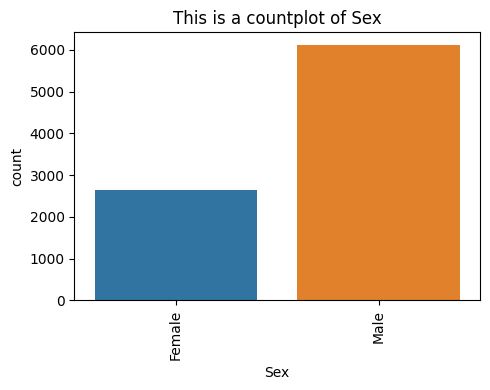

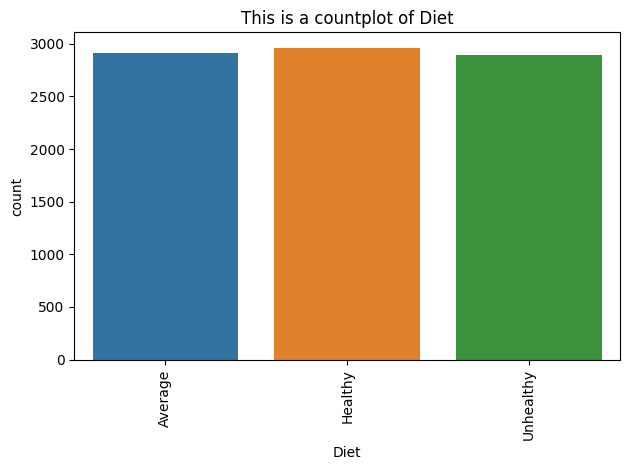

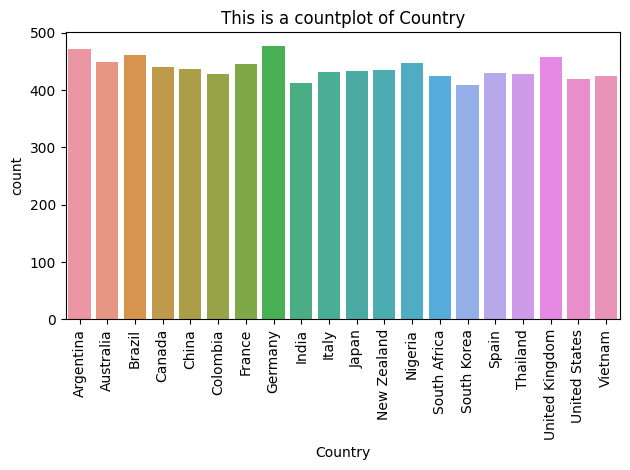

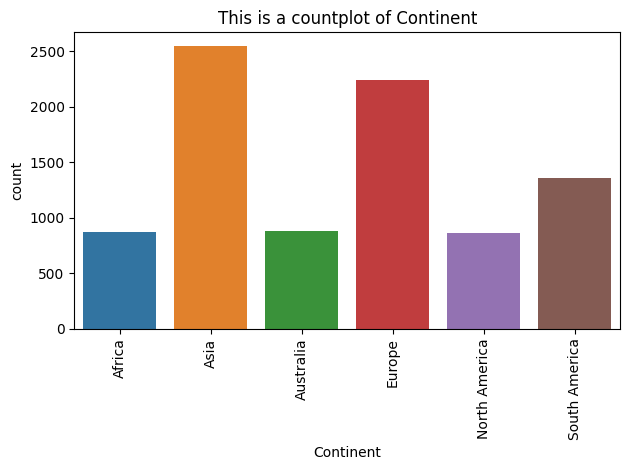

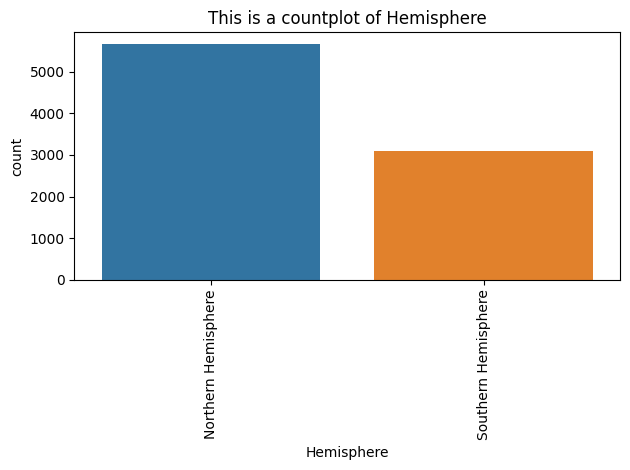

In [38]:
# Create Countplots
plt.figure(figsize=(5, 4))
#Explanation:
#This line creates a new figure with a specified figure size. 
#The figsize parameter sets the width and height of the figure in inches.
#In this case, the width is set to 5 inches, and the height is set to 4 inches.

count_plot_columns = ["Sex", "Diet", "Country", "Continent", "Hemisphere"]
for i in count_plot_columns:
    sns.countplot(x= i, data = df)
    plt.title(f'This is a countplot of {i}')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

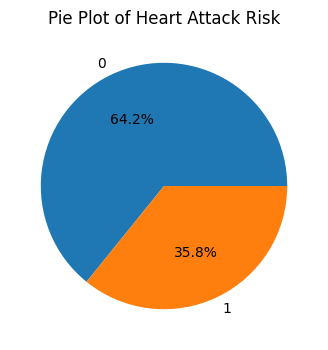

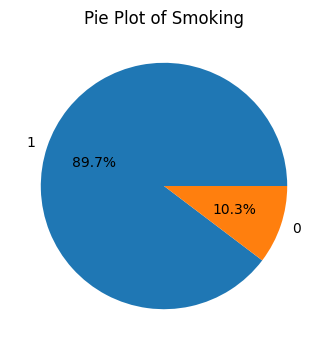

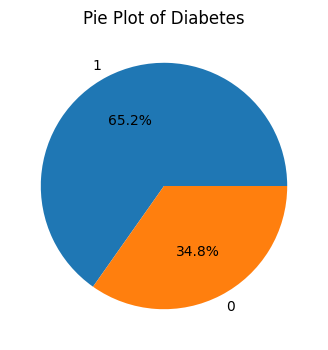

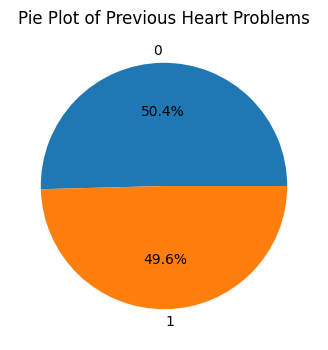

In [39]:
pie_plot_columns = ["Heart Attack Risk", "Smoking", "Diabetes", "Previous Heart Problems"]

for pie_columns in pie_plot_columns:
    plt.figure(figsize=(5, 4))
    counts = df[pie_columns].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(f'Pie Plot of {pie_columns}')
    plt.show()

In [40]:
df

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk,Active Hours
0,67,Male,208,158/88,72,0,0,1,0,0,...,-740,31.250000,286,0,6,Argentina,South America,Southern Hemisphere,0,17.390625
1,21,Male,389,165/93,98,1,1,1,1,1,...,23624,27.187500,235,1,7,Canada,North America,Northern Hemisphere,0,19.031250
2,21,Female,324,174/99,72,1,0,0,0,0,...,-26862,28.171875,587,4,4,France,Europe,Northern Hemisphere,0,14.539062
3,84,Male,383,163/100,73,1,1,1,0,1,...,-5432,36.468750,378,3,4,Canada,North America,Northern Hemisphere,0,16.343750
4,66,Male,318,91/88,93,1,1,1,1,0,...,29483,21.812500,231,1,5,Thailand,Asia,Northern Hemisphere,0,22.484375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,Male,121,94/76,61,1,1,1,0,1,...,-26724,19.656250,67,7,7,Thailand,Asia,Northern Hemisphere,0,13.195312
8759,28,Female,120,157/102,73,1,0,0,1,0,...,21273,24.000000,617,4,9,Canada,North America,Northern Hemisphere,0,20.171875
8760,47,Male,250,161/75,105,0,1,1,1,1,...,-28538,35.406250,527,4,4,Brazil,South America,Southern Hemisphere,1,21.625000
8761,36,Male,178,119/67,60,1,0,1,0,0,...,13335,27.296875,114,2,8,Brazil,South America,Southern Hemisphere,0,23.968750


In [41]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=['int16', 'float16'])
numeric_columns

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Heart Attack Risk,Active Hours
0,67,208,72,0,0,1,0,0,4.167969,0,0,9,6.613281,-740,31.250000,286,0,6,0,17.390625
1,21,389,98,1,1,1,1,1,1.813477,1,0,1,4.964844,23624,27.187500,235,1,7,0,19.031250
2,21,324,72,1,0,0,0,0,2.078125,1,1,9,9.460938,-26862,28.171875,587,4,4,0,14.539062
3,84,383,73,1,1,1,0,1,9.828125,1,0,9,7.648438,-5432,36.468750,378,3,4,0,16.343750
4,66,318,93,1,1,1,1,0,5.804688,1,0,6,1.514648,29483,21.812500,231,1,5,0,22.484375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,121,61,1,1,1,0,1,7.917969,1,1,8,10.804688,-26724,19.656250,67,7,7,0,13.195312
8759,28,120,73,1,0,0,1,0,16.562500,0,0,8,3.833984,21273,24.000000,617,4,9,0,20.171875
8760,47,250,105,0,1,1,1,1,3.148438,1,0,5,2.375000,-28538,35.406250,527,4,4,1,21.625000
8761,36,178,60,1,0,1,0,0,3.789062,1,1,5,0.029099,13335,27.296875,114,2,8,0,23.968750


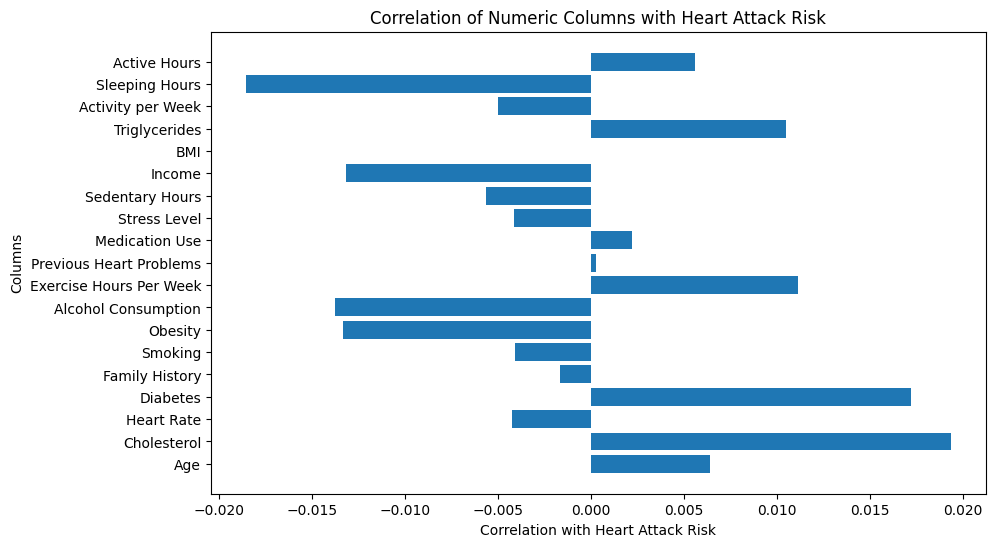

In [42]:
#Delete the Heart Attack Risk column from the new dataset
numeric_columns.drop("Heart Attack Risk",axis=1,inplace=True)

# Calculate correlation with Heart Attack Risk
correlation = numeric_columns.corrwith(df['Heart Attack Risk'])
score = correlation 

# Plot correlation
plt.figure(figsize=(10, 6))
plt.barh(score.index, score)
plt.xlabel('Correlation with Heart Attack Risk')
plt.ylabel('Columns')
plt.title('Correlation of Numeric Columns with Heart Attack Risk')
plt.show()

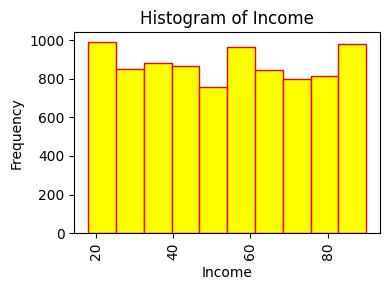

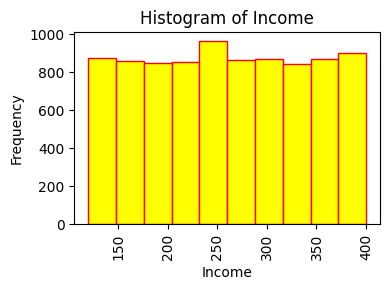

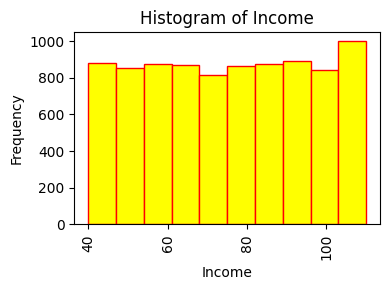

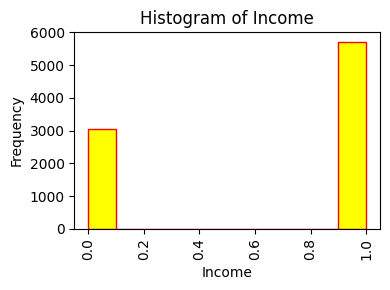

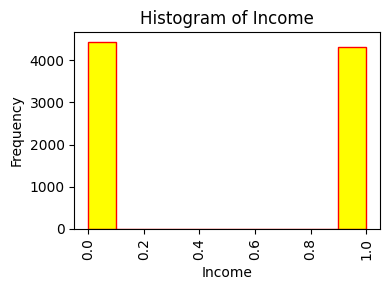

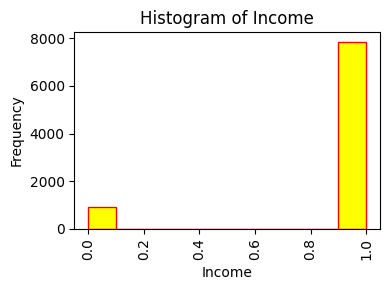

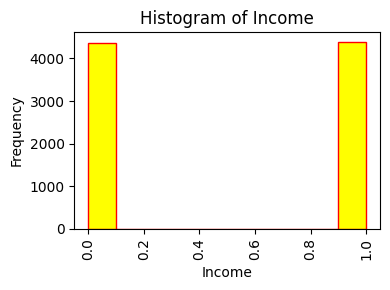

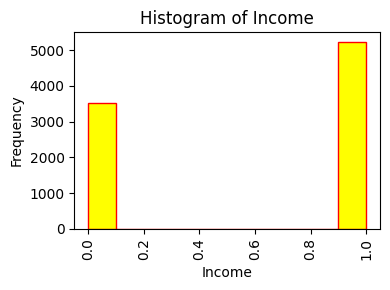

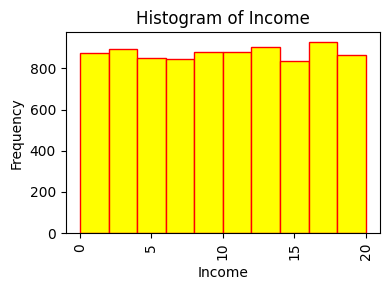

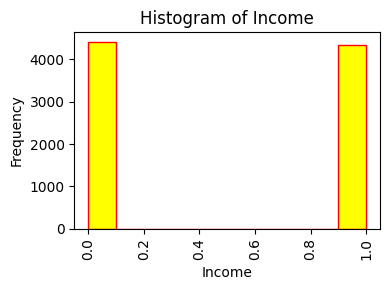

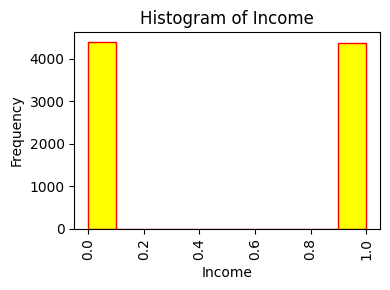

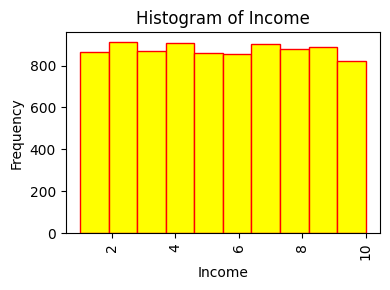

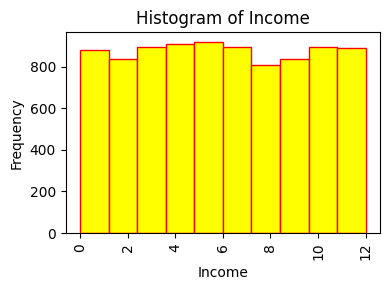

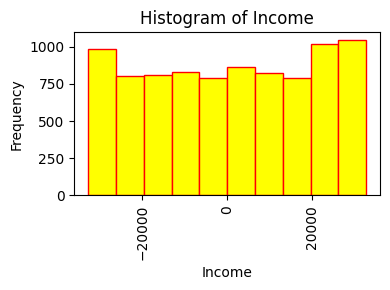

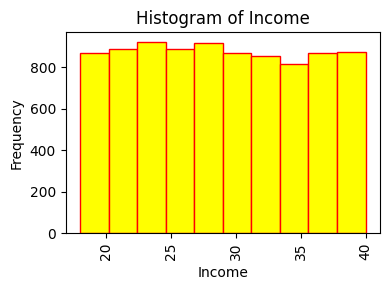

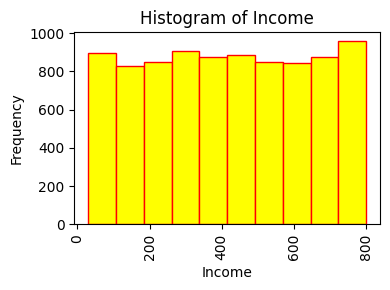

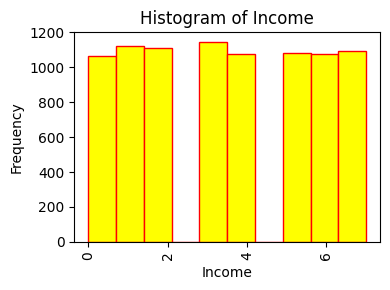

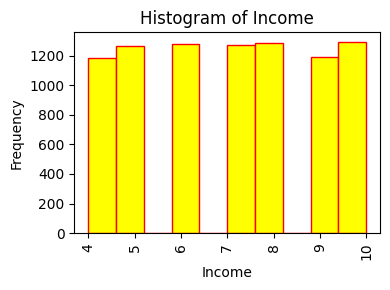

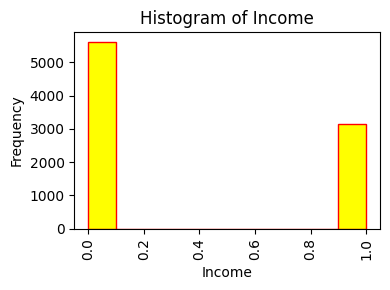

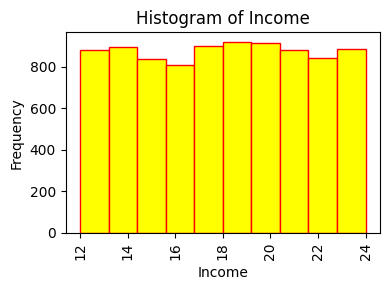

In [43]:
histogram_columns = ["Income", "BMI", "Age"]

for hist_columns in columns:
    plt.figure(figsize=(4, 3))
    plt.hist(df[hist_columns], color='yellow', edgecolor='red')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.xticks(rotation=90)
    plt.tight_layout()  # Adjust subplot layout to avoid overlapping
    plt.show()  # Display the plot


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


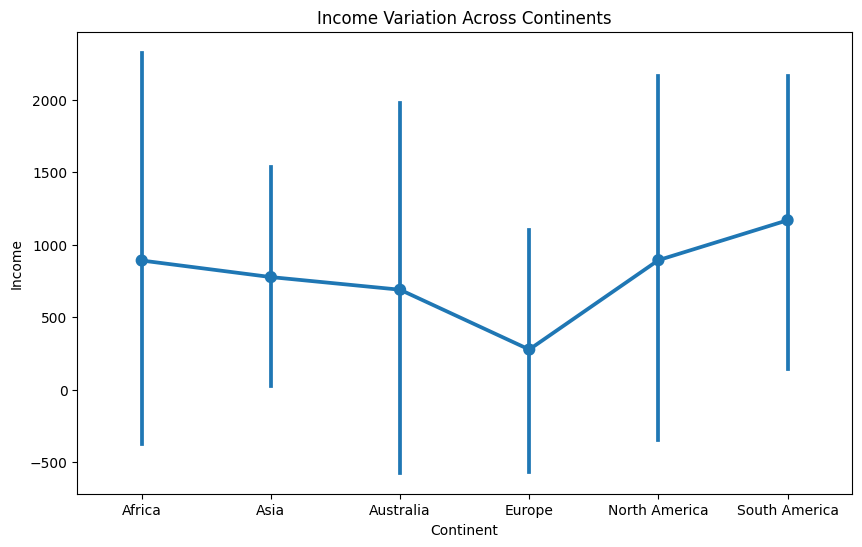

In [44]:
# Create Pointplot
plt.figure(figsize=(10, 6))  # Create a new figure with specified size (width=10, height=6)

# Create a point plot using Seaborn's pointplot function
sns.pointplot(data=df, x='Continent', y='Income')
# 'data=df' specifies the DataFrame containing the data
# 'x='Continent'' specifies the variable to be plotted on the x-axis, which is 'Continent'
# 'y='Income'' specifies the variable to be plotted on the y-axis, which is 'Income'

plt.xlabel('Continent')  # Set label for x-axis
plt.ylabel('Income')  # Set label for y-axis
plt.title('Income Variation Across Continents')  # Set title for the plot
plt.show()  # Display the plot


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


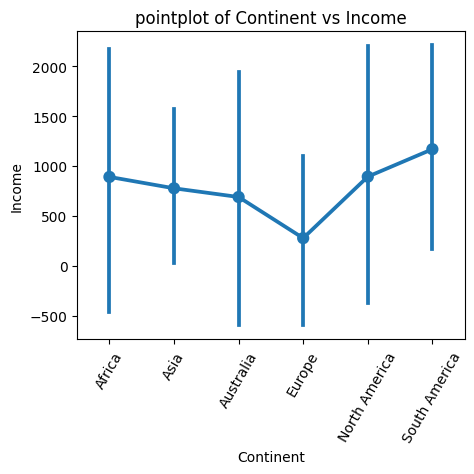

In [45]:
#Same task done by a simple code 
plt.figure(figsize=(5,4))
sns.pointplot(data = df, x="Continent", y="Income")
plt.title('pointplot of Continent vs Income')
plt.xticks(rotation=60)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


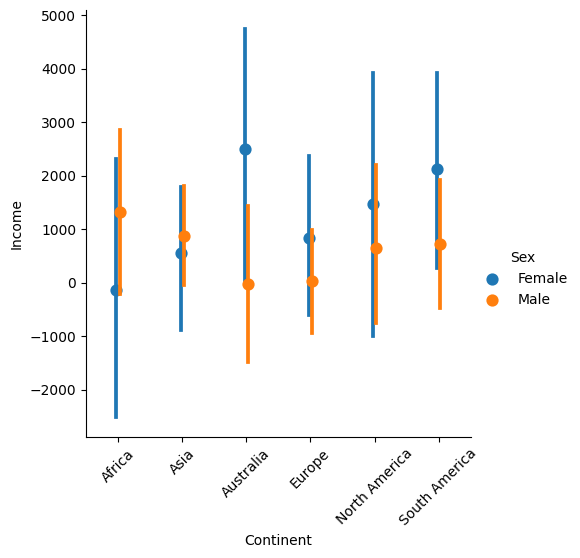

In [46]:
x_column = 'Continent'

# Selecting a numeric column for y-axis
y_column = 'Heart Attack Risk'

# Create the point plot
sns.catplot(data=df, x=x_column, y="Income", kind="point", hue="Sex", join=False, dodge=True)

plt.xticks(rotation=45)

plt.show()

In [47]:
# Step 1
# Make a correlation graph to check the correlation of "Heart Attack Risk" with other columns.

numeric_columns = df.select_dtypes(include = "number") # select only numeric columns

correlation_score = numeric_columns.corr() # find the correlation score of columns

correlation_score

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours,Income,BMI,Triglycerides,Activity per Week,Sleeping Hours,Heart Attack Risk,Active Hours
Age,1.000000,-0.009107,-0.003844,-0.014105,0.008353,0.394891,-0.008140,-0.006666,0.001202,0.000868,0.000980,0.018307,0.017279,0.006174,-0.002613,0.003415,0.001384,-0.002185,0.006403,-0.017285
Cholesterol,-0.009107,1.000000,0.000315,-0.013428,-0.021608,0.016342,-0.014843,-0.007261,0.021515,-0.006070,-0.000905,-0.024487,0.018914,-0.001404,0.017276,-0.005454,0.016056,0.004456,0.019340,-0.018920
Heart Rate,-0.003844,0.000315,1.000000,0.006764,-0.013470,-0.012331,0.012725,0.003459,0.008278,-0.004956,0.009244,-0.004547,-0.010230,0.006324,0.005301,0.012244,0.000834,0.001811,-0.004251,0.010235
Diabetes,-0.014105,-0.013428,0.006764,1.000000,-0.013844,0.000527,0.012866,0.005551,-0.007009,0.000867,-0.002656,0.006719,0.004698,-0.005965,-0.002855,0.010431,-0.002411,-0.012457,0.017225,-0.004672
Family History,0.008353,-0.021608,-0.013470,-0.013844,1.000000,0.011748,-0.001444,0.012701,-0.006380,-0.004568,0.000981,0.015637,0.002573,-0.004196,-0.011487,-0.001904,0.009561,-0.011199,-0.001652,-0.002576
Smoking,0.394891,0.016342,-0.012331,0.000527,0.011748,1.000000,0.003969,0.012754,-0.000149,-0.000574,-0.010877,-0.001757,0.015305,-0.014976,0.007679,0.004650,-0.006465,-0.005424,-0.004051,-0.015303
Obesity,-0.008140,-0.014843,0.012725,0.012866,-0.001444,0.003969,1.000000,-0.024195,0.002099,0.005159,-0.006267,0.010626,-0.001332,-0.000992,-0.006041,0.001467,0.005337,-0.005314,-0.013318,0.001364
Alcohol Consumption,-0.006666,-0.007261,0.003459,0.005551,0.012701,0.012754,-0.024195,1.000000,-0.008513,0.010395,0.003339,-0.005023,-0.012828,-0.026984,0.010566,0.006169,0.001593,-0.000843,-0.013778,0.012814
Exercise Hours Per Week,0.001202,0.021515,0.008278,-0.007009,-0.006380,-0.000149,0.002099,-0.008513,1.000000,0.005252,-0.007128,-0.009097,0.008756,-0.003249,0.003792,0.001714,0.007725,-0.001243,0.011133,-0.008761
Previous Heart Problems,0.000868,-0.006070,-0.004956,0.000867,-0.004568,-0.000574,0.005159,0.010395,0.005252,1.000000,0.005336,-0.017629,-0.002695,0.010750,0.015710,-0.019029,0.008537,0.004460,0.000274,0.002682


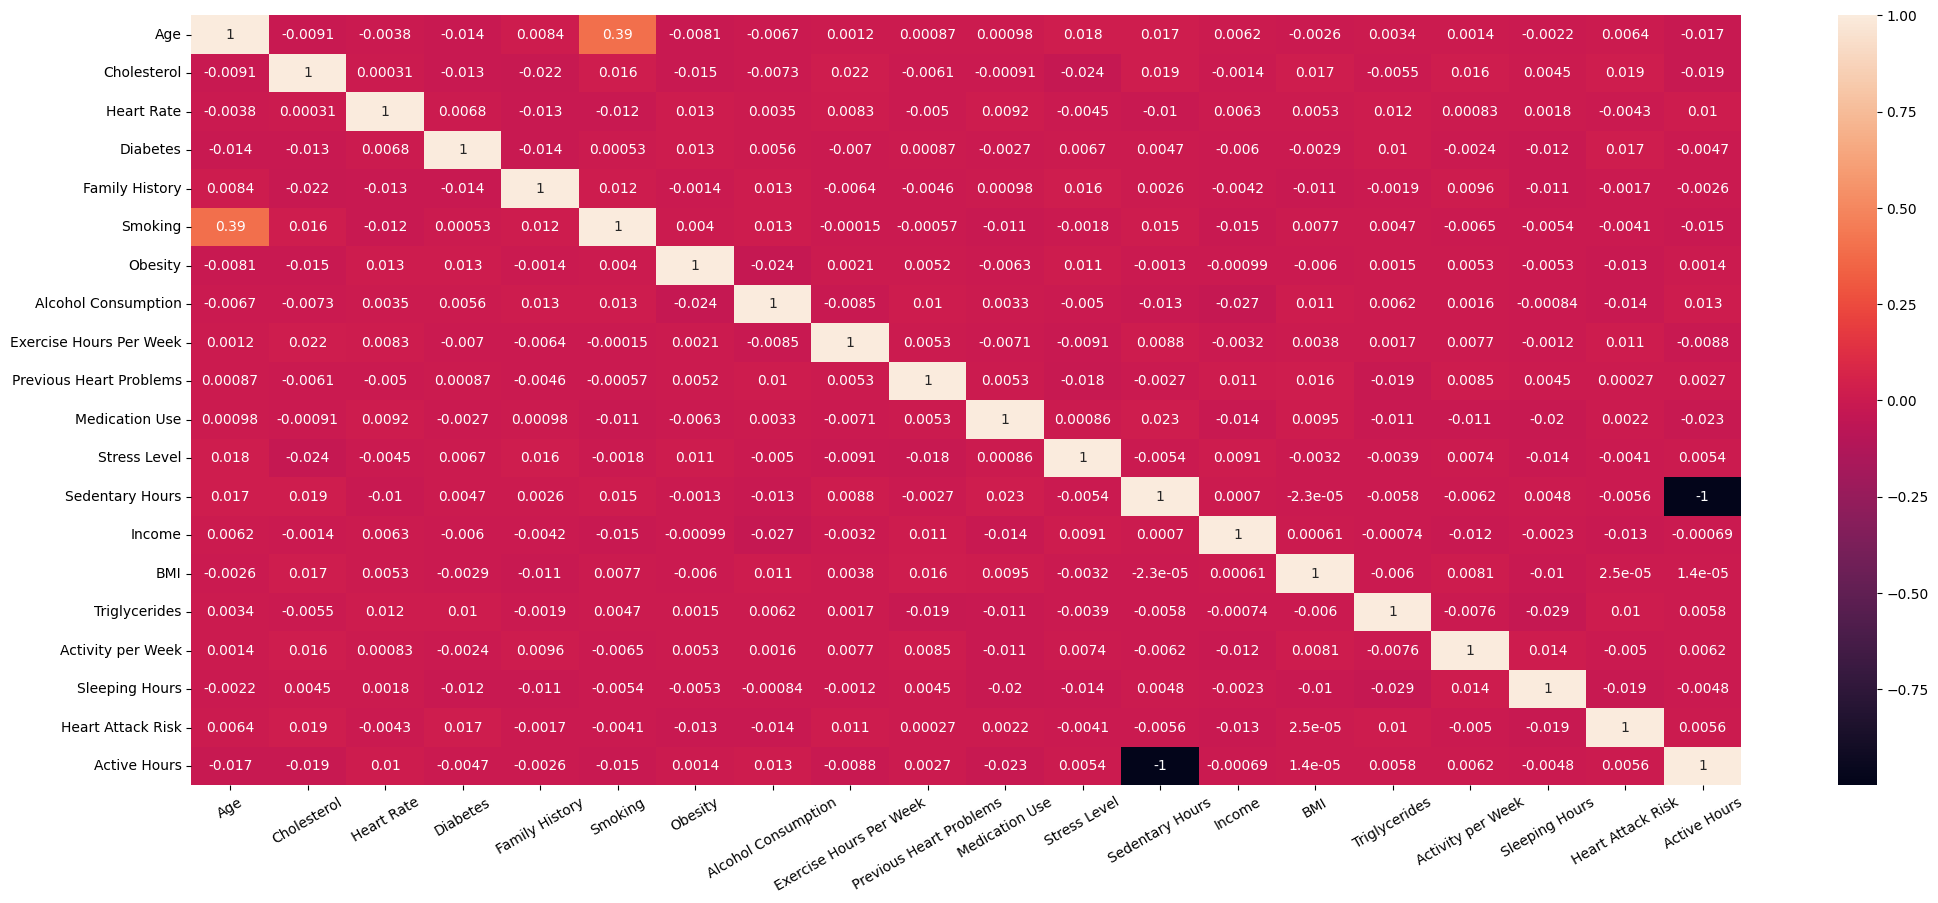

In [48]:
# Step 1 (continued)

plt.figure(figsize=(25, 10)) # set the figure size so that it is neither too small nor too large

sns.heatmap(correlation_score, annot=True) # create the heatmap and also show the score #annotate  represent the values in heat map

plt.xticks(rotation=30) # rotata x axis labels

plt.show()

In [49]:
# Step 2
# Identify / Find out which columns have dtype category.

categorical_columns = df.select_dtypes("category").columns
categorical_columns

Index(['Sex', 'Blood Pressure', 'Diet', 'Country', 'Continent', 'Hemisphere'], dtype='object')

In [50]:
# Step 3
# Convert Blood Pressure column into 2 new columns systolic and dysystolic with dtype of int

bp_splitted = df["Blood Pressure"].str.split("/", expand = True)

bp_splitted

,0,1
0,158,88
1,165,93
2,174,99
3,163,100
4,91,88
...,...,...
8758,94,76
8759,157,102
8760,161,75
8761,119,67


In [51]:
# Step 3 (continued)

df["systolic"] = bp_splitted[0] # get the first column values and create systolic column
df["dysystolic"] = bp_splitted[1] # get the second column values and create dysystolic column

# convert dtype into int
df["systolic"] = df["systolic"].astype("int32")
df["dysystolic"]  = df["dysystolic"].astype("int32")

# check to see of new columns have been converted into int dtype
print(df["systolic"].dtype)
print(df["dysystolic"].dtype)


# drop/delete Blood Pressure column
del df["Blood Pressure"]

# print the df
df.head()

int32
int32


,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Triglycerides,Activity per Week,Sleeping Hours,Country,Continent,Hemisphere,Heart Attack Risk,Active Hours,systolic,dysystolic
0,67,Male,208,72,0,0,1,0,0,4.167969,...,286,0,6,Argentina,South America,Southern Hemisphere,0,17.390625,158,88
1,21,Male,389,98,1,1,1,1,1,1.813477,...,235,1,7,Canada,North America,Northern Hemisphere,0,19.031250,165,93
2,21,Female,324,72,1,0,0,0,0,2.078125,...,587,4,4,France,Europe,Northern Hemisphere,0,14.539062,174,99
3,84,Male,383,73,1,1,1,0,1,9.828125,...,378,3,4,Canada,North America,Northern Hemisphere,0,16.343750,163,100
4,66,Male,318,93,1,1,1,1,0,5.804688,...,231,1,5,Thailand,Asia,Northern Hemisphere,0,22.484375,91,88


In [52]:
# Step 4
# Apply ordinal encoding on 'Diet' column.

print(df["Diet"].unique()) # first check the unique values in the Diet column

print()

# define the mapping of values
value_map = {
    "Unhealthy" : 1,
    "Average" : 2,
    "Healthy" : 3
}

# convert the values of Diet column into numbers

df["Diet"] = df["Diet"].map(value_map)

print(df["Diet"].unique()) # check unique values again to check they have been converted

# Because previously Diet column was a category. So now change its dtype to int
df["Diet"] = df["Diet"].astype("int32")

['Average', 'Unhealthy', 'Healthy']
Categories (3, object): ['Average', 'Healthy', 'Unhealthy']

[2, 1, 3]
Categories (3, int64): [2, 3, 1]


In [53]:
# Step 5
# Convert columns ['Sex', 'Country', 'Continent', 'Hemisphere' ] into numbers using get_dummies function

df = pd.get_dummies(df, columns = ['Sex', 'Country', 'Continent', 'Hemisphere' ], drop_first=True)

# print the data frame
df.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Country_Thailand,Country_United Kingdom,Country_United States,Country_Vietnam,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Southern Hemisphere
0,67,208,72,0,0,1,0,0,4.167969,2,...,False,False,False,False,False,False,False,False,True,True
1,21,389,98,1,1,1,1,1,1.813477,1,...,False,False,False,False,False,False,False,True,False,False
2,21,324,72,1,0,0,0,0,2.078125,3,...,False,False,False,False,False,False,True,False,False,False
3,84,383,73,1,1,1,0,1,9.828125,2,...,False,False,False,False,False,False,False,True,False,False
4,66,318,93,1,1,1,1,0,5.804688,1,...,True,False,False,False,True,False,False,False,False,False


In [54]:
# Step 6
# Convert the boolean columns into numbers

# first select all columns with dtype bool

bool_columns = df.select_dtypes(include = "bool").columns

bool_columns

Index(['Sex_Male', 'Country_Australia', 'Country_Brazil', 'Country_Canada',
       'Country_China', 'Country_Colombia', 'Country_France',
       'Country_Germany', 'Country_India', 'Country_Italy', 'Country_Japan',
       'Country_New Zealand', 'Country_Nigeria', 'Country_South Africa',
       'Country_South Korea', 'Country_Spain', 'Country_Thailand',
       'Country_United Kingdom', 'Country_United States', 'Country_Vietnam',
       'Continent_Asia', 'Continent_Australia', 'Continent_Europe',
       'Continent_North America', 'Continent_South America',
       'Hemisphere_Southern Hemisphere'],
      dtype='object')

In [55]:
# Step 6 (continued)

for bool_col in bool_columns:
    df[bool_col] = df[bool_col].astype("int32")

In [56]:
# Step 7
# Check the dtypes to make sure they are changed.

df.dtypes

Age                                 int16
Cholesterol                         int16
Heart Rate                          int16
Diabetes                            int16
Family History                      int16
Smoking                             int16
Obesity                             int16
Alcohol Consumption                 int16
Exercise Hours Per Week           float16
Diet                                int32
Previous Heart Problems             int16
Medication Use                      int16
Stress Level                        int16
Sedentary Hours                   float16
Income                              int16
BMI                               float16
Triglycerides                       int16
Activity per Week                   int16
Sleeping Hours                      int16
Heart Attack Risk                   int16
Active Hours                      float16
systolic                            int32
dysystolic                          int32
Sex_Male                          

In [57]:
# Step 8
# Seaparate the target variable and remaining data

X = df.drop("Heart Attack Risk", axis = 1)
y = df["Heart Attack Risk"]

In [58]:
X.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Country_Thailand,Country_United Kingdom,Country_United States,Country_Vietnam,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Southern Hemisphere
0,67,208,72,0,0,1,0,0,4.167969,2,...,0,0,0,0,0,0,0,0,1,1
1,21,389,98,1,1,1,1,1,1.813477,1,...,0,0,0,0,0,0,0,1,0,0
2,21,324,72,1,0,0,0,0,2.078125,3,...,0,0,0,0,0,0,1,0,0,0
3,84,383,73,1,1,1,0,1,9.828125,2,...,0,0,0,0,0,0,0,1,0,0
4,66,318,93,1,1,1,1,0,5.804688,1,...,1,0,0,0,1,0,0,0,0,0


In [59]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Heart Attack Risk, dtype: int16

In [ ]:
# Step 9
# Split the dataset

# import train_test_split function

# from sklearn.model_selection import train_test_split

# # split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
# X_train.head()

In [ ]:
# X_test.head()

In [60]:
# Step 1
# Identify numeric columns with more than 10 unique values
# This helps us avoid scaling binary columns

nunique_10 = df.nunique() > 10

nunique_10

Age                                True
Cholesterol                        True
Heart Rate                         True
Diabetes                          False
Family History                    False
Smoking                           False
Obesity                           False
Alcohol Consumption               False
Exercise Hours Per Week            True
Diet                              False
Previous Heart Problems           False
Medication Use                    False
Stress Level                      False
Sedentary Hours                    True
Income                             True
BMI                                True
Triglycerides                      True
Activity per Week                 False
Sleeping Hours                    False
Heart Attack Risk                 False
Active Hours                       True
systolic                           True
dysystolic                         True
Sex_Male                          False
Country_Australia                 False


In [61]:
# Step1 (continued)
# Get the names of columns which have more than 10 unique values

cols_to_scale = df.loc[:, nunique_10].columns

print(cols_to_scale)

Index(['Age', 'Cholesterol', 'Heart Rate', 'Exercise Hours Per Week',
       'Sedentary Hours', 'Income', 'BMI', 'Triglycerides', 'Active Hours',
       'systolic', 'dysystolic'],
      dtype='object')


In [62]:
# Step 2
# Check the value counts of y variable which contains "Heart Attack Risk" values
# This helps us to see the imbalancen in dataset

y.value_counts(normalize=True) # show in percentage

Heart Attack Risk
0    0.641789
1    0.358211
Name: proportion, dtype: float64

In [63]:
# Step 3
# import SMOTE & create a new dataset in which classes have equal representaion

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 365)

# apply smote technique on X and y

X_smote, y_smote = smote.fit_resample(X, y)

In [64]:
# Step 4
# Check the value_counts of y_smote to see that imbalance is removed

y_smote.value_counts(normalize = True)

Heart Attack Risk
0    0.5
1    0.5
Name: proportion, dtype: float64

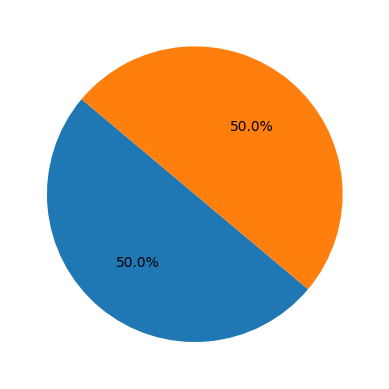

In [65]:
# Step 4 (continued)
# Visulaize value_counts of y_smote

plt.pie(y_smote.value_counts(), autopct="%1.1f%%", startangle = 140)
plt.show()

In [66]:
# Step 5
# split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2)

In [67]:
print(f"""

Rows in X_train: {X_train.shape[0]}
Rows in y_train: {y_train.shape[0]}

Rows in X_test: {X_test.shape[0]}
Rows in y_test: {y_test.shape[0]} 

""")



Rows in X_train: 8998
Rows in y_train: 8998

Rows in X_test: 2250
Rows in y_test: 2250 




In [68]:
# Step 6
# Scale the values of cols_to_transform using RobustScaler

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaler.fit( X_train[cols_to_scale] )

X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [69]:
# Step 7
# 1. import the models

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [70]:
# Step 7 (continued)
# 2. train GaussianNB model

clf = GaussianNB()

clf.fit(X_train, y_train)

clf_score = clf.score(X_test, y_test)

print(clf_score * 100)

67.02222222222223


In [71]:
# Step 7 (continued)
# 3. train LogisticRegression model

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_score = lr.score(X_test, y_test)

print(lr_score * 100)

69.91111111111111


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [72]:
# Step 7 (continued)
# 4. train DecisionTreeClassifier model

dtr = DecisionTreeClassifier()

dtr.fit(X_train, y_train)

dtr_score = dtr.score(X_test, y_test)

print(dtr_score * 100)


60.75555555555555


In [73]:
# Step 7 (continued)
# 4. train RandomForestClassifier model

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_score = rf.score(X_test, y_test)

print(rf_score * 100)


69.46666666666667


In [74]:
# Step 7 (continued)
# 4. train KNeighborsClassifier model

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_score = knn.score(X_test, y_test)

print(knn_score * 100)


59.599999999999994


In [75]:
# Step 8
# Get predictions of each model
# Store the name of model as key and predictions as value in a dictionary

models = [clf, lr, dtr, rf, knn]

model_predictions = {}

for model in models:
    model_name = str(model).split("(")[0]
    
    model_predictions[model_name] = model.predict(X_test)
    
print(model_predictions)

{'GaussianNB': array([1, 0, 1, ..., 0, 0, 1], dtype=int16), 'LogisticRegression': array([0, 0, 0, ..., 0, 0, 0], dtype=int16), 'DecisionTreeClassifier': array([0, 0, 0, ..., 1, 0, 0], dtype=int16), 'RandomForestClassifier': array([0, 0, 1, ..., 0, 1, 0], dtype=int16), 'KNeighborsClassifier': array([1, 1, 1, ..., 1, 1, 0], dtype=int16)}


In [ ]:
# Step 9
# Evaluate the performance of models
# Use metrics accuracy_score, f1_score, precision_score, recall_score for evaluation
# Store the evaluation result in a dictionary

from sklearn.metrics import accuracy_score, \
                            f1_score, precision_score, recall_score


model_evaluation = {}


for model, preds in model_predictions.items():
# #    Print Statements to see how we can build the logic for population model_evaluation
#     print(model, "\n")
#     print(round(accuracy_score(y_test, preds), 2))
#     print(round(f1_score(y_test, preds), 2))
#     print(round(precision_score(y_test, preds), 2))
#     print(round(recall_score(y_test, preds), 2))
#     print("\n\n\n")


    model_evaluation[model] = [
        round(accuracy_score(y_test, preds) * 100, 2) ,
        round(f1_score(y_test, preds) * 100, 2),
        round(precision_score(y_test, preds) * 100, 2) ,
        round(recall_score(y_test, preds) * 100, 2),
    ]

In [ ]:
results_df = pd.DataFrame(model_evaluation, index=["Accuracy", "F1 Score", "Precision", "Recall"])

results_df.style.background_gradient(axis=None, cmap="bone")

,GaussianNB,LogisticRegression,DecisionTreeClassifier,RandomForestClassifier,KNeighborsClassifier
Accuracy,67.020000,69.910000,60.760000,69.470000,59.600000
F1 Score,60.410000,57.610000,61.220000,63.200000,67.030000
Precision,76.280000,98.920000,60.870000,80.270000,56.860000
Recall,50.000000,40.640000,61.570000,52.120000,81.630000
